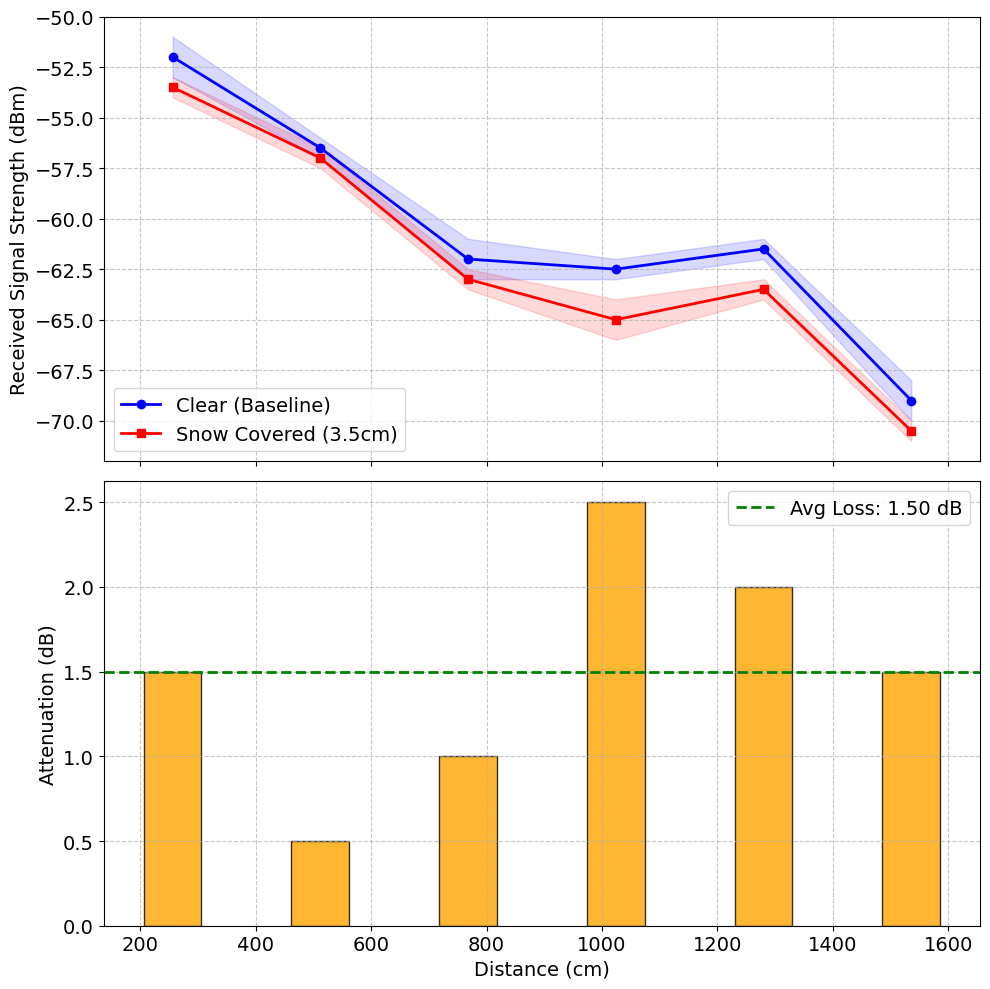

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
# Choose how to display the min/max ranges in the top plot:
# 'errorbar' : Shows traditional vertical +/- lines (I-beams)
# 'fill'     : Shows a shaded area between the min and max values
RANGE_STYLE = 'fill' 

LABEL_FONT_SIZE = 14
TICK_FONT_SIZE = 14
LEGEND_FONT_SIZE = 14
ANNOTATION_FONT_SIZE = 10
# ---------------------

# Corrected distances (256cm / 2.56m jumps per block)
distances = np.array([256, 512, 768, 1024, 1280, 1536])

# Exact data from notebook (Clear)
clear_avg = np.array([-52.0, -56.5, -62.0, -62.5, -61.5, -69.0])
clear_min = np.array([-53.0, -57.0, -63.0, -63.0, -62.0, -70.0])
clear_max = np.array([-51.0, -56.0, -61.0, -62.0, -61.0, -68.0])

# Exact data from notebook (Snow)
snow_avg = np.array([-53.5, -57.0, -63.0, -65.0, -63.5, -70.5])
snow_min = np.array([-54.0, -57.5, -63.5, -66.0, -64.0, -71.0])
snow_max = np.array([-53.0, -56.5, -62.5, -64.0, -63.0, -70.0])

# Attenuation
attenuation_mag = clear_avg - snow_avg

# Calculate error bar magnitudes [lower_err, upper_err] for matplotlib
clear_err = [clear_avg - clear_min, clear_max - clear_avg]
snow_err = [snow_avg - snow_min, snow_max - snow_avg]

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Subplot 1: Signal Strength
ax1.set_ylabel('Received Signal Strength (dBm)', fontsize=LABEL_FONT_SIZE)
ax1.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)
ax1.grid(True, linestyle='--', alpha=0.7)

if RANGE_STYLE == 'errorbar':
    ax1.errorbar(distances, clear_avg, yerr=clear_err, label='Clear (Baseline)', 
                 color='blue', marker='o', linestyle='-', linewidth=2, capsize=5)
    ax1.errorbar(distances, snow_avg, yerr=snow_err, label='Snow Covered (3.5cm)', 
                 color='red', marker='s', linestyle='-', linewidth=2, capsize=5)

elif RANGE_STYLE == 'fill':
    ax1.plot(distances, clear_avg, label='Clear (Baseline)', color='blue', marker='o', linewidth=2)
    ax1.fill_between(distances, clear_min, clear_max, color='blue', alpha=0.15)
    
    ax1.plot(distances, snow_avg, label='Snow Covered (3.5cm)', color='red', marker='s', linewidth=2)
    ax1.fill_between(distances, snow_min, snow_max, color='red', alpha=0.15)

ax1.legend(loc='lower left', fontsize=LEGEND_FONT_SIZE)

# Subplot 2: Attenuation (Bar chart)
ax2.set_xlabel('Distance (cm)', fontsize=LABEL_FONT_SIZE)
ax2.set_ylabel('Attenuation (dB)', fontsize=LABEL_FONT_SIZE)
ax2.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)
ax2.grid(True, linestyle='--', alpha=0.7)

# Bar chart for attenuation 
bars = ax2.bar(distances, attenuation_mag, color='orange', alpha=0.8, edgecolor='black', width=100)

# for bar in bars:
#     height = bar.get_height()
#     ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
#              f'{height:.1f} dB',
#              ha='center', va='bottom', fontsize=ANNOTATION_FONT_SIZE, fontweight='bold')

avg_loss = np.mean(attenuation_mag)
ax2.axhline(avg_loss, color='green', linestyle='--', linewidth=2, label=f'Avg Loss: {avg_loss:.2f} dB')
ax2.legend(loc='upper right', fontsize=LEGEND_FONT_SIZE)

plt.tight_layout()
plt.savefig('snow_attenuation_plot.png')
plt.show()

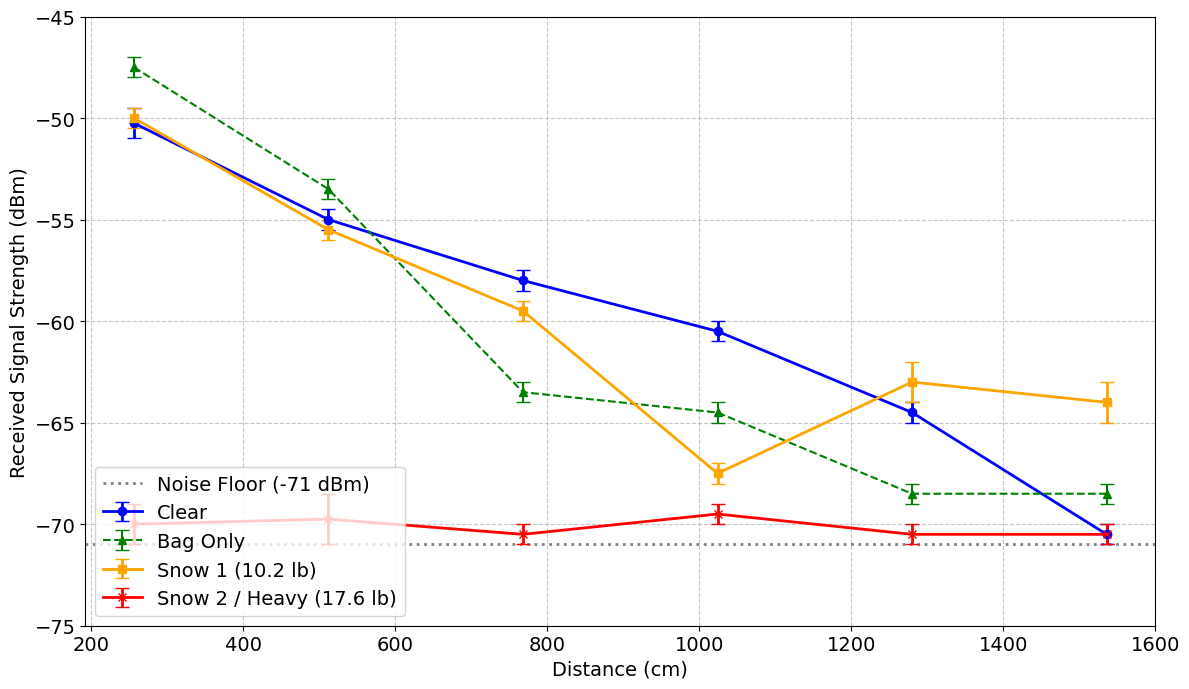

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
PLOT_STYLE = 'errorbar' # Options: 'errorbar' or 'fill'
INCLUDE_HEAVY_SNOW_RAIN = True # Set to False to hide the 69 to -71 dBm data

LABEL_FONT_SIZE = 14
TICK_FONT_SIZE = 14
LEGEND_FONT_SIZE = 14
# ---------------------

# Distances in cm (2.56m jumps per block)
distances = np.array([256, 512, 768, 1024, 1280, 1536])

# --- Data Extraction from Notebook (PAAM) ---
# Format: [Loc 1, Loc 2, Loc 3, Loc 4, Loc 5, Loc 6]
# Note: Converting notebook positive numbers to negative dBm 

# Clear (Baseline)
clear_min = np.array([-51.0, -55.5, -58.5, -61.0, -65.0, -71.0])
clear_max = np.array([-49.5, -54.5, -57.5, -60.0, -64.0, -70.0])
clear_avg = (clear_min + clear_max) / 2

# Bag (Control)
bag_min = np.array([-48.0, -54.0, -64.0, -65.0, -69.0, -69.0])
bag_max = np.array([-47.0, -53.0, -63.0, -64.0, -68.0, -68.0])
bag_avg = (bag_min + bag_max) / 2

# Snow 1 (10.2 lb)
snow1_min = np.array([-50.5, -56.0, -60.0, -68.0, -64.0, -65.0])
snow1_max = np.array([-49.5, -55.0, -59.0, -67.0, -62.0, -63.0])
snow1_avg = (snow1_min + snow1_max) / 2

# Snow 2 / Rain (17.6 lb) - Bouncing along the -71 dBm noise floor
snow2_min = np.array([-71.0, -71.0, -71.0, -70.0, -71.0, -71.0])
snow2_max = np.array([-69.0, -68.5, -70.0, -69.0, -70.0, -70.0])
snow2_avg = (snow2_min + snow2_max) / 2

# Calculate error bar sizes for Matplotlib [lower_err, upper_err]
def calc_err(avg, min_val, max_val):
    return [avg - min_val, max_val - avg]

clear_err = calc_err(clear_avg, clear_min, clear_max)
bag_err = calc_err(bag_avg, bag_min, bag_max)
snow1_err = calc_err(snow1_avg, snow1_min, snow1_max)
snow2_err = calc_err(snow2_avg, snow2_min, snow2_max)

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.set_xlabel('Distance (cm)', fontsize=LABEL_FONT_SIZE)
ax1.set_ylabel('Received Signal Strength (dBm)', fontsize=LABEL_FONT_SIZE)
ax1.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)
ax1.grid(True, linestyle='--', alpha=0.7)

# Set lower limit to show the -71 dBm floor clearly
ax1.set_ylim(-75, -45) 
ax1.axhline(-71, color='gray', linestyle=':', linewidth=2, label='Noise Floor (-71 dBm)')

if PLOT_STYLE == 'errorbar':
    ax1.errorbar(distances, clear_avg, yerr=clear_err, label='Clear', 
                 color='blue', marker='o', linestyle='-', linewidth=2, capsize=5)
    
    ax1.errorbar(distances, bag_avg, yerr=bag_err, label='Bag Only', 
                 color='green', marker='^', linestyle='--', linewidth=1.5, capsize=5)
                 
    ax1.errorbar(distances, snow1_avg, yerr=snow1_err, label='Snow 1 (10.2 lb)', 
                 color='orange', marker='s', linestyle='-', linewidth=2, capsize=5)
                 
    if INCLUDE_HEAVY_SNOW_RAIN:
        ax1.errorbar(distances, snow2_avg, yerr=snow2_err, label='Snow 2 / Heavy (17.6 lb)', 
                     color='red', marker='x', linestyle='-', linewidth=2, capsize=5)

elif PLOT_STYLE == 'fill':
    ax1.plot(distances, clear_avg, label='Clear', color='blue', marker='o', linewidth=2)
    ax1.fill_between(distances, clear_min, clear_max, color='blue', alpha=0.15)
    
    ax1.plot(distances, bag_avg, label='Bag Only', color='green', marker='^', linestyle='--', linewidth=1.5)
    ax1.fill_between(distances, bag_min, bag_max, color='green', alpha=0.1)
    
    ax1.plot(distances, snow1_avg, label='Snow (10.2 lb)', color='orange', marker='s', linewidth=2)
    ax1.fill_between(distances, snow1_min, snow1_max, color='orange', alpha=0.15)
    
    if INCLUDE_HEAVY_SNOW_RAIN:
        ax1.plot(distances, snow2_avg, label='Snow  Heavy (17.6 lb)', color='red', marker='x', linewidth=2)
        ax1.fill_between(distances, snow2_min, snow2_max, color='red', alpha=0.15)

ax1.legend(loc='lower left', fontsize=LEGEND_FONT_SIZE)

plt.tight_layout()
plt.savefig('paam_signal_strength_plot.png')
plt.show()